### Imports / Load

In [ ]:
import matplotlib.pyplot as plt
import xarray as xr
import ee

import sys
sys.path.append("..")

# ee.Authenticate()  # only needed once
ee.Initialize(project="climate-pollinator-explorer")

#lat_max, lon_min, lat_min, lon_max
area = [61.0, -8.0, 49.5, 2.0]

import src.data.ndvi
import src.data.spei
import src.data.landcover
import importlib
importlib.reload(src.data.ndvi)
importlib.reload(src.data.spei)
importlib.reload(src.data.landcover)

<module 'src.data.landcover' from '/home/alf_walks/projects/python/climate-pollinator-explorer/backend/notebooks/../src/data/landcover.py'>

### Temperature

In [6]:
from src.data.era5 import load_era5

ds = load_era5(year=2021, month=7, days=['01', '02', '03'], area=area)

print(ds)


2026-07-17 10:40:34,524 INFO Request ID is 8b1367b2-dac3-4b38-8b35-47e4feadcb8b
2026-07-17 10:40:34,604 INFO status has been updated to accepted
2026-07-17 10:40:58,811 INFO status has been updated to running
2026-07-17 10:41:12,320 INFO status has been updated to successful
                                                                                        

<xarray.Dataset> Size: 47kB
Dimensions:     (valid_time: 3, latitude: 47, longitude: 41)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 24B 2021-07-01T12:00:00 ... 2021-...
    expver      (valid_time) <U4 48B ...
  * latitude    (latitude) float64 376B 61.0 60.75 60.5 ... 50.0 49.75 49.5
  * longitude   (longitude) float64 328B -8.0 -7.75 -7.5 -7.25 ... 1.5 1.75 2.0
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 23kB 283.1 ... 293.9
    t2m_C       (valid_time, latitude, longitude) float32 23kB 9.922 ... 20.76
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-17T08:57 GRIB to CDM+CF via cfgrib-0.9.1...


### NDVI

In [26]:
from src.data.ndvi import load_ndvi

ndvi_da, ndvi_np = load_ndvi("2021-07-01", "2021-07-31", area)
ndvi_regridded = ndvi_da.interp(lat=ds.latitude, lon=ds.longitude, method="linear")

print(ndvi_regridded.shape)

print(ndvi_da.min().item(), ndvi_da.max().item())


(47, 41)
-0.1997 0.9916


### SPEI

In [8]:
from src.data.spei import load_spei
import numpy as np

spei_pilot = load_spei("2021-07-16", area)
spei_pilot = spei_pilot.sortby("lat")

spei_regridded = spei_pilot.interp(lat=ds.latitude.values, lon=ds.longitude.values, method="nearest")

print("NaN count:", np.isnan(spei_regridded["spei"].values).sum())
print("Total cells:", spei_regridded["spei"].values.size)
print("Min/Max (ignoring NaN):", np.nanmin(spei_regridded["spei"].values), np.nanmax(spei_regridded["spei"].values))

NaN count: 0
Total cells: 1927
Min/Max (ignoring NaN): -2.047683 2.130431


### BLines

In [12]:
from src.data.bline import load_blines

blines_exploded, blines_clip = load_blines(area)

print(blines_exploded.shape)
print(blines_clip.shape)

(198, 4)
(1, 4)


### Land Cover

In [11]:
from src.data.landcover import load_landcover
lc_da , lc_np = load_landcover(area)
lc_regridded = lc_da.interp(lat=ds.latitude.values, lon=ds.longitude.values, method="nearest")
print(lc_regridded.shape)
print(np.unique(lc_regridded.values))
print(np.isnan(lc_regridded.values).sum(), "/", lc_regridded.values.size)

(47, 41)
[ 0. 10. 30. 40. 50. 80. 90. nan]
133 / 1927


### Flowering Season

In [13]:
from src.data.flowering import flowering_score
print(flowering_score(7))

1.0


### Plots

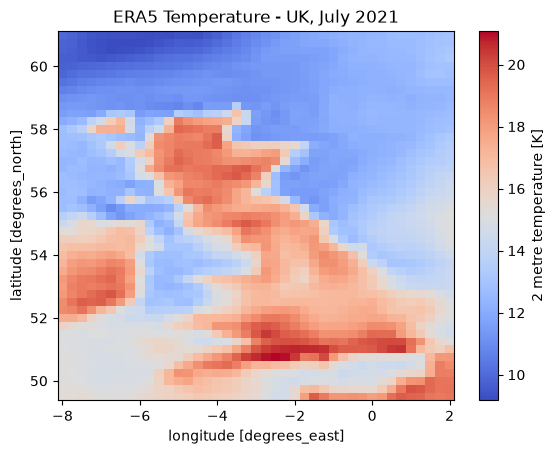

In [20]:
ds["t2m_C"].isel(valid_time=0).plot(cmap="coolwarm")
plt.title("ERA5 Temperature - UK, July 2021")
plt.show()

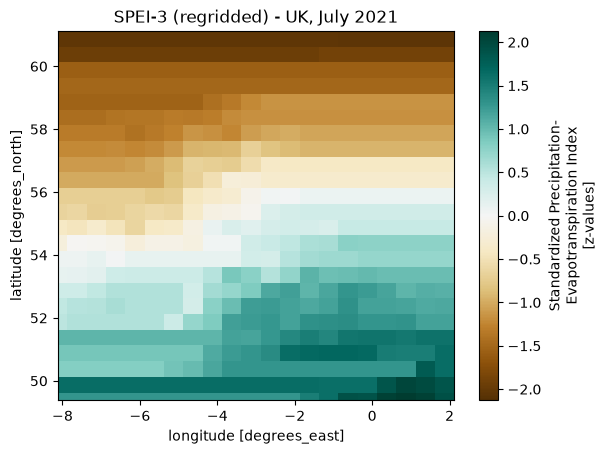

In [21]:
spei_regridded["spei"].plot(cmap="BrBG")
plt.title("SPEI-3 (regridded) - UK, July 2021")
plt.show()

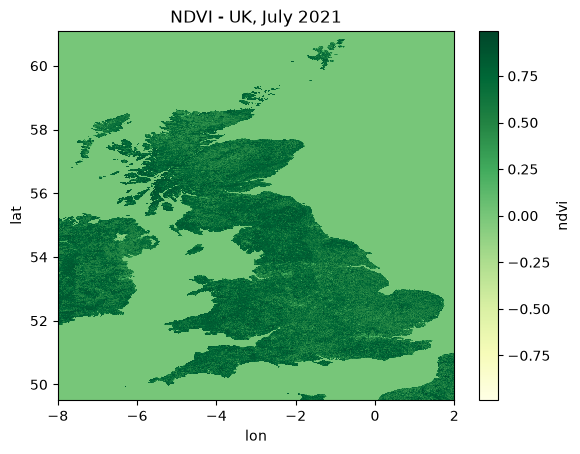

In [22]:
ndvi_da.plot(cmap="YlGn")
plt.title("NDVI - UK, July 2021")
plt.show()

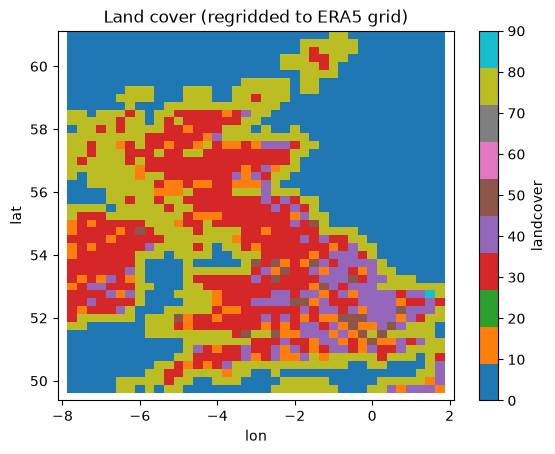

In [23]:
lc_regridded.plot(cmap="tab10")
plt.title("Land cover (regridded to ERA5 grid)")
plt.show()

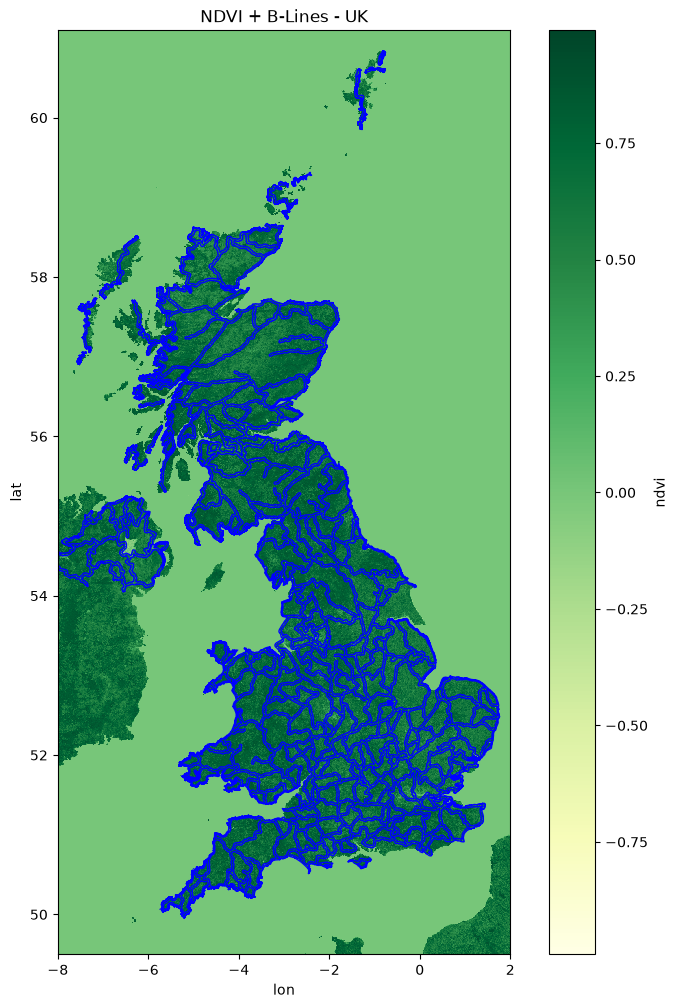

In [25]:
fig, ax = plt.subplots(figsize=(10,12))
ndvi_da.plot(ax=ax, cmap="YlGn")
blines_clip.plot(ax=ax, color="none", edgecolor="blue", linewidth=1)
plt.title("NDVI + B-Lines - UK")
plt.show()

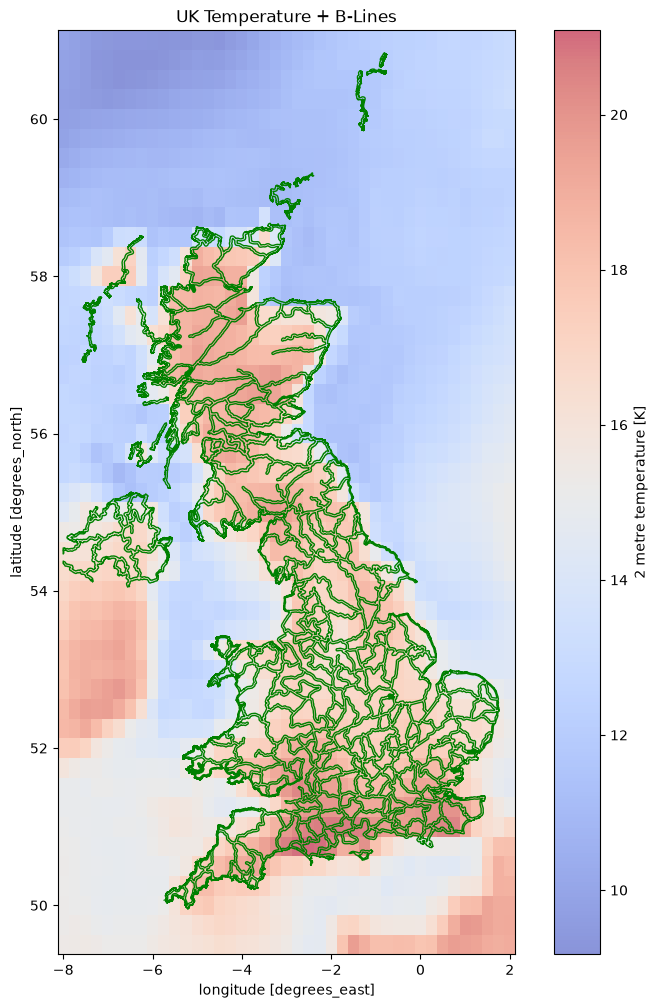

In [24]:
fig, ax = plt.subplots(figsize=(10,12))
ds["t2m_C"].isel(valid_time=0).plot(ax=ax, cmap="coolwarm", alpha=0.6)
blines_clip.plot(ax=ax, color="none", edgecolor="green", linewidth=1)
plt.title("UK Temperature + B-Lines")
plt.show()

### Save Loaded Data

In [32]:
import os
import xarray as xr

era5_t2m = ds["t2m_C"].isel(valid_time=0)
era5_t2m = era5_t2m.drop_vars(["number", "valid_time", "expver"], errors="ignore")
era5_t2m = era5_t2m.rename({"latitude": "lat", "longitude": "lon"})
era5_t2m.name = "temperature"

spei_da = spei_regridded["spei"]
spei_da = spei_da.drop_vars(["time", "number"], errors="ignore")

ndvi_da_final = ndvi_regridded.drop_vars(["number", "band", "spatial_ref", "latitude", "longitude"], errors="ignore")
ndvi_da_final = ndvi_da_final.rename({"latitude": "lat", "longitude": "lon"})
ndvi_da_final.name = "ndvi"

lc_da_final = lc_regridded.drop_vars(["number", "band", "spatial_ref", "latitude", "longitude"], errors="ignore")
lc_da_final.name = "landcover"

print("temperature:", era5_t2m.dims)
print("spei:       ", spei_da.dims)
print("ndvi:       ", ndvi_da_final.dims)
print("landcover:  ", lc_da_final.dims)

finalds = xr.merge([era5_t2m, spei_da, ndvi_da_final, lc_da_final])
print(finalds)

os.makedirs("../data_cache/loadedData", exist_ok=True)
finalds.to_netcdf(path="../data_cache/loadedData/uk_aligned.nc")
blines_exploded.to_file("../data_cache/loadedData/uk_blines_exploded.gpkg")

print("Saved uk_aligned.nc and uk_blines_exploded.gpkg")

/tmp/ipykernel_22340/313639575.py:13: UserWarning: rename 'latitude' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ndvi_da_final = ndvi_da_final.rename({"latitude": "lat", "longitude": "lon"})
/tmp/ipykernel_22340/313639575.py:13: UserWarning: rename 'longitude' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ndvi_da_final = ndvi_da_final.rename({"latitude": "lat", "longitude": "lon"})


temperature: ('lat', 'lon')
spei:        ('lat', 'lon')
ndvi:        ('lat', 'lon')
landcover:   ('lat', 'lon')
<xarray.Dataset> Size: 47kB
Dimensions:      (lat: 47, lon: 41)
Coordinates:
  * lat          (lat) float64 376B 61.0 60.75 60.5 60.25 ... 50.0 49.75 49.5
  * lon          (lon) float64 328B -8.0 -7.75 -7.5 -7.25 ... 1.25 1.5 1.75 2.0
Data variables:
    temperature  (lat, lon) float32 8kB 9.922 9.781 9.629 ... 19.04 18.96 19.07
    spei         (lat, lon) float32 8kB -2.034 -2.034 -2.034 ... 1.918 1.918
    ndvi         (lat, lon) float64 15kB nan 0.0 0.0 0.0 0.0 ... nan nan nan nan
    landcover    (lat, lon) float64 15kB nan 0.0 0.0 0.0 0.0 ... nan nan nan nan
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1927
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            